In [20]:
import obspy
from obspy import read
import matplotlib.pyplot as plt

## First Shot

In [21]:
st1 = read(r"../Data/1001.dat")

In [22]:
print(st1)

72 Trace(s) in Stream:

... | 2026-05-21T12:38:07.000000Z - 2026-05-21T12:38:08.999750Z | 4000.0 Hz, 8000 samples
...
(70 other traces)
...
... | 2026-05-21T12:38:07.000000Z - 2026-05-21T12:38:08.999750Z | 4000.0 Hz, 8000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


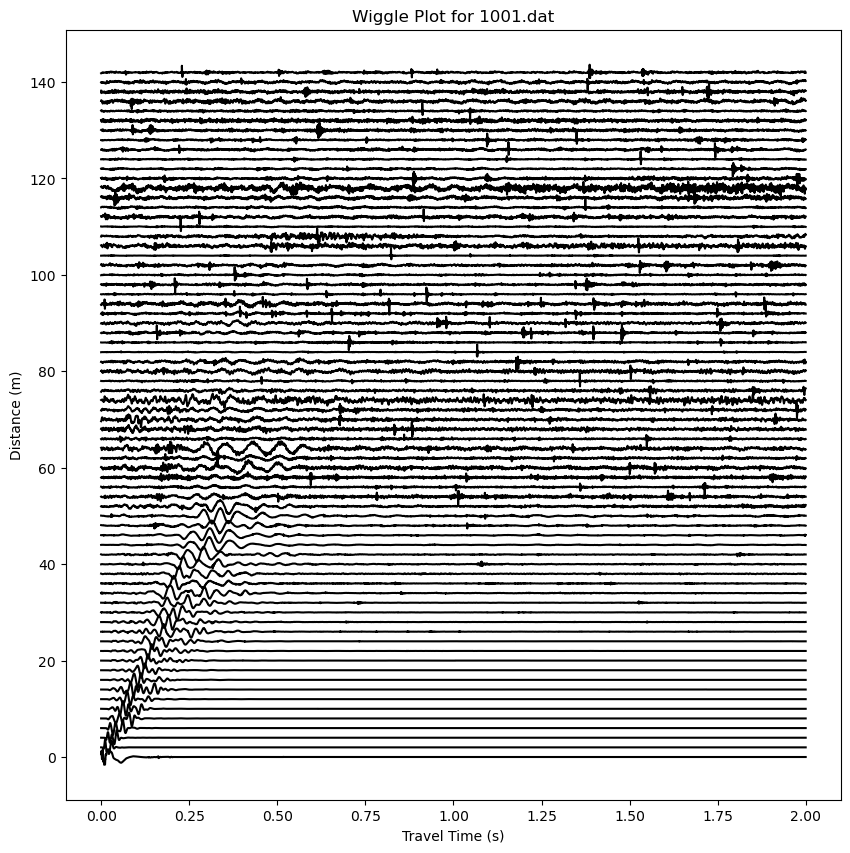

In [23]:
# create image with pyplot.
# y axis is distance in meters (geophones 2 m apart), x axis is travel time in seconds.

scale = 1
separation = 2  # geophones are 2 m apart

plt.figure(figsize=(10, 10))

for ch in range(72):
    tr = st1[ch]
    data = tr.data
    times = tr.times()
    plt.plot(times, 0.8*separation*data/abs(data).max()+ch*separation, color='black')

plt.title("Wiggle Plot for 1001.dat")
plt.xlabel("Travel Time (s)")
plt.ylabel("Distance (m)")
plt.show()


## Middle Shot

In [24]:
st6 = read(r"../Data/1006.dat")

In [25]:
print(st6)

72 Trace(s) in Stream:

... | 2026-05-21T13:22:28.000000Z - 2026-05-21T13:22:29.999750Z | 4000.0 Hz, 8000 samples
...
(70 other traces)
...
... | 2026-05-21T13:22:28.000000Z - 2026-05-21T13:22:29.999750Z | 4000.0 Hz, 8000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


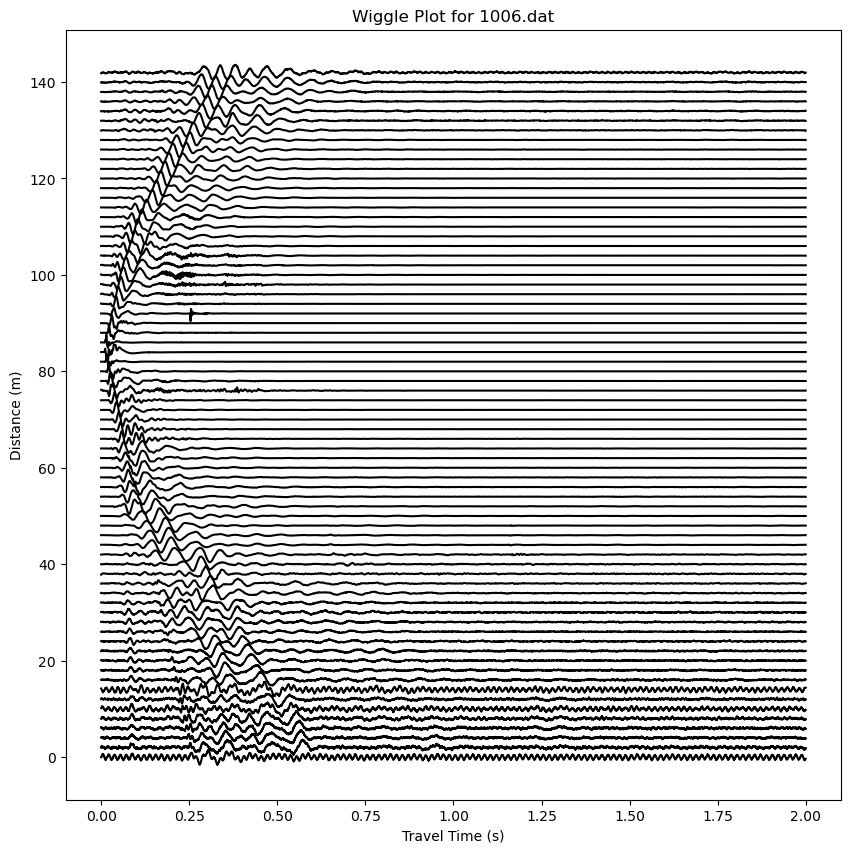

In [26]:
scale = 1
separation = 2  

plt.figure(figsize=(10, 10))

for ch in range(72):
    tr = st6[ch]
    data = tr.data
    times = tr.times()
    plt.plot(times, 0.8*separation*data/abs(data).max()+ch*separation, color='black')

plt.title("Wiggle Plot for 1006.dat")
plt.xlabel("Travel Time (s)")
plt.ylabel("Distance (m)")
plt.show()


## Last Shot

In [27]:
st9 = read(r"../Data/1009.dat")

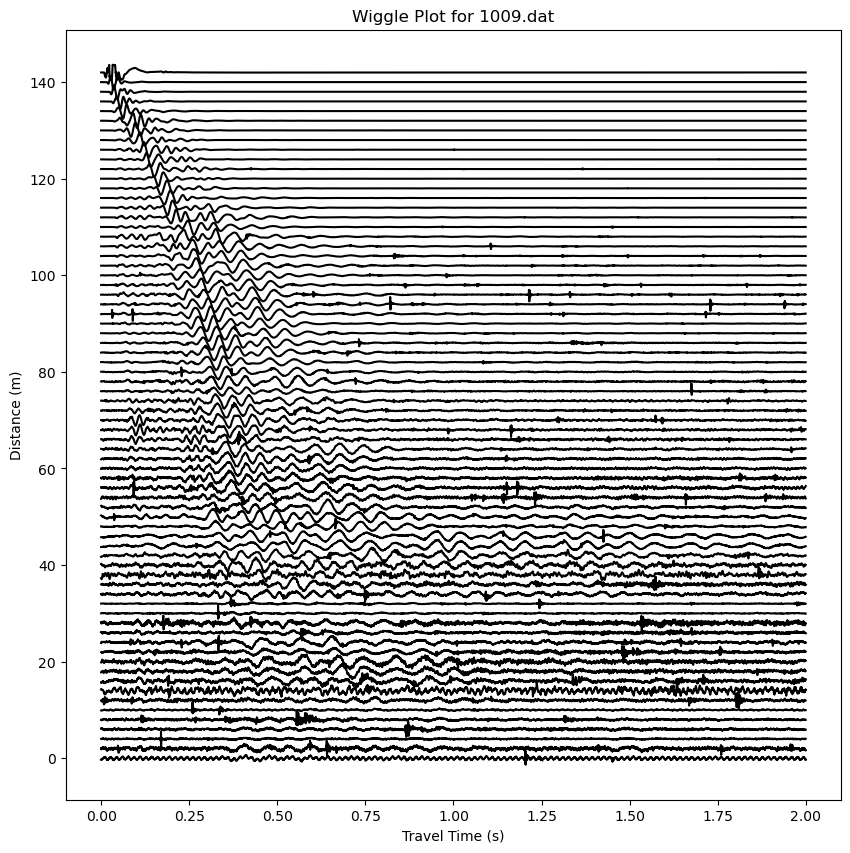

In [28]:
scale = 1
separation = 2  # geophones are 2 m apart

plt.figure(figsize=(10, 10))

for ch in range(72):
    tr = st9[ch]
    data = tr.data
    times = tr.times()
    plt.plot(times, 0.8*separation*data/abs(data).max()+ch*separation, color='black')

plt.title("Wiggle Plot for 1009.dat")
plt.xlabel("Travel Time (s)")
plt.ylabel("Distance (m)")
plt.show()


## Loop: per-side velocity model for every Critter Springs shot

For every shot in `corrected_all_cs_picks_40-5hz_firsthits.sgt`, the t–x curve on each side of the shot is fit **independently** — no mirroring. The number of layers per side (1, 2, or 3) is chosen automatically by BIC, so a side without a clear slope break gets a 1-layer fit. Apparent velocities must increase with offset for a multi-layer fit to be accepted.

- **Left side** = geophones at offsets < shot position (red)
- **Right side** = geophones at offsets > shot position (blue)
- Solid line = layer 1, dashed = layer 2, dotted = layer 3
- Depths come from the standard flat-layer intercept-time formulas.


In [29]:
import numpy as np

# ---- parse a Refrapick .sgt file ----
def read_sgt(path):
    with open(path, "r") as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    n_pts = int(lines[0].split()[0])
    i = 1
    if lines[i].startswith("#"):
        i += 1
    sensors = np.array([list(map(float, lines[i + k].split()))
                        for k in range(n_pts)])
    i += n_pts
    n_meas = int(lines[i].split()[0]); i += 1
    if lines[i].startswith("#"):
        i += 1
    meas = np.array([list(map(float, lines[i + k].split()))
                     for k in range(n_meas)])
    return sensors, meas

# ---- helpers: per-side piecewise refraction fit ----
def _line_fit(x, t):
    s, i = np.polyfit(x, t, 1)
    sse = float(np.sum((s*x + i - t)**2))
    return s, i, sse

def fit_piecewise(x, t, kmax=3, min_per_seg=3):
    """Fit a piecewise-linear t-x model with k = 1..kmax segments.

    Constraints
    -----------
    - each segment has >= min_per_seg points
    - slopes strictly decrease (so apparent velocities increase with offset)

    Selection
    ---------
    k is chosen by BIC = n*log(SSE/n) + (3k - 1)*log(n).

    Returns
    -------
    dict with keys k, breaks (segment-end indices, exclusive of last),
    slopes, intercepts, sse, bic.  None if no fit is possible.
    """
    n = len(x)
    candidates = []

    if n >= min_per_seg:
        s1, i1, sse = _line_fit(x, t)
        candidates.append({"k":1, "breaks":[], "slopes":[s1],
                           "intercepts":[i1], "sse":sse})

    if n >= 2*min_per_seg and kmax >= 2:
        best = None
        for b in range(min_per_seg, n - min_per_seg + 1):
            s1, i1, e1 = _line_fit(x[:b], t[:b])
            s2, i2, e2 = _line_fit(x[b:], t[b:])
            if s2 >= s1:
                continue
            sse = e1 + e2
            if best is None or sse < best["sse"]:
                best = {"k":2, "breaks":[b], "slopes":[s1,s2],
                        "intercepts":[i1,i2], "sse":sse}
        if best is not None:
            candidates.append(best)

    if n >= 3*min_per_seg and kmax >= 3:
        best = None
        for b1 in range(min_per_seg, n - 2*min_per_seg + 1):
            for b2 in range(b1 + min_per_seg, n - min_per_seg + 1):
                s1, i1, e1 = _line_fit(x[:b1], t[:b1])
                s2, i2, e2 = _line_fit(x[b1:b2], t[b1:b2])
                s3, i3, e3 = _line_fit(x[b2:], t[b2:])
                if not (s1 > s2 > s3):
                    continue
                sse = e1 + e2 + e3
                if best is None or sse < best["sse"]:
                    best = {"k":3, "breaks":[b1,b2], "slopes":[s1,s2,s3],
                            "intercepts":[i1,i2,i3], "sse":sse}
        if best is not None:
            candidates.append(best)

    if not candidates:
        return None

    for c in candidates:
        p = 3*c["k"] - 1
        c["bic"] = n * np.log(max(c["sse"], 1e-20) / n) + p * np.log(n)
    return min(candidates, key=lambda c: c["bic"])


def depths_from_fit(fit):
    """Cumulative depths to each refractor (m) from intercept times (flat layers)."""
    v  = [1.0/s for s in fit["slopes"]]
    ti = fit["intercepts"]
    depths = []
    if len(v) >= 2:
        V1, V2 = v[0], v[1]
        h1 = ti[1] * V1*V2 / (2.0 * np.sqrt(V2**2 - V1**2))
        depths.append(h1)
        if len(v) >= 3:
            V3 = v[2]
            term = ti[2] - 2*h1*np.sqrt(1.0/V1**2 - 1.0/V3**2)
            h2 = term * V2*V3 / (2.0 * np.sqrt(V3**2 - V2**2))
            depths.append(h1 + h2)
    return v, depths


9 shots: [1, 7, 13, 19, 31, 43, 55, 67, 72]


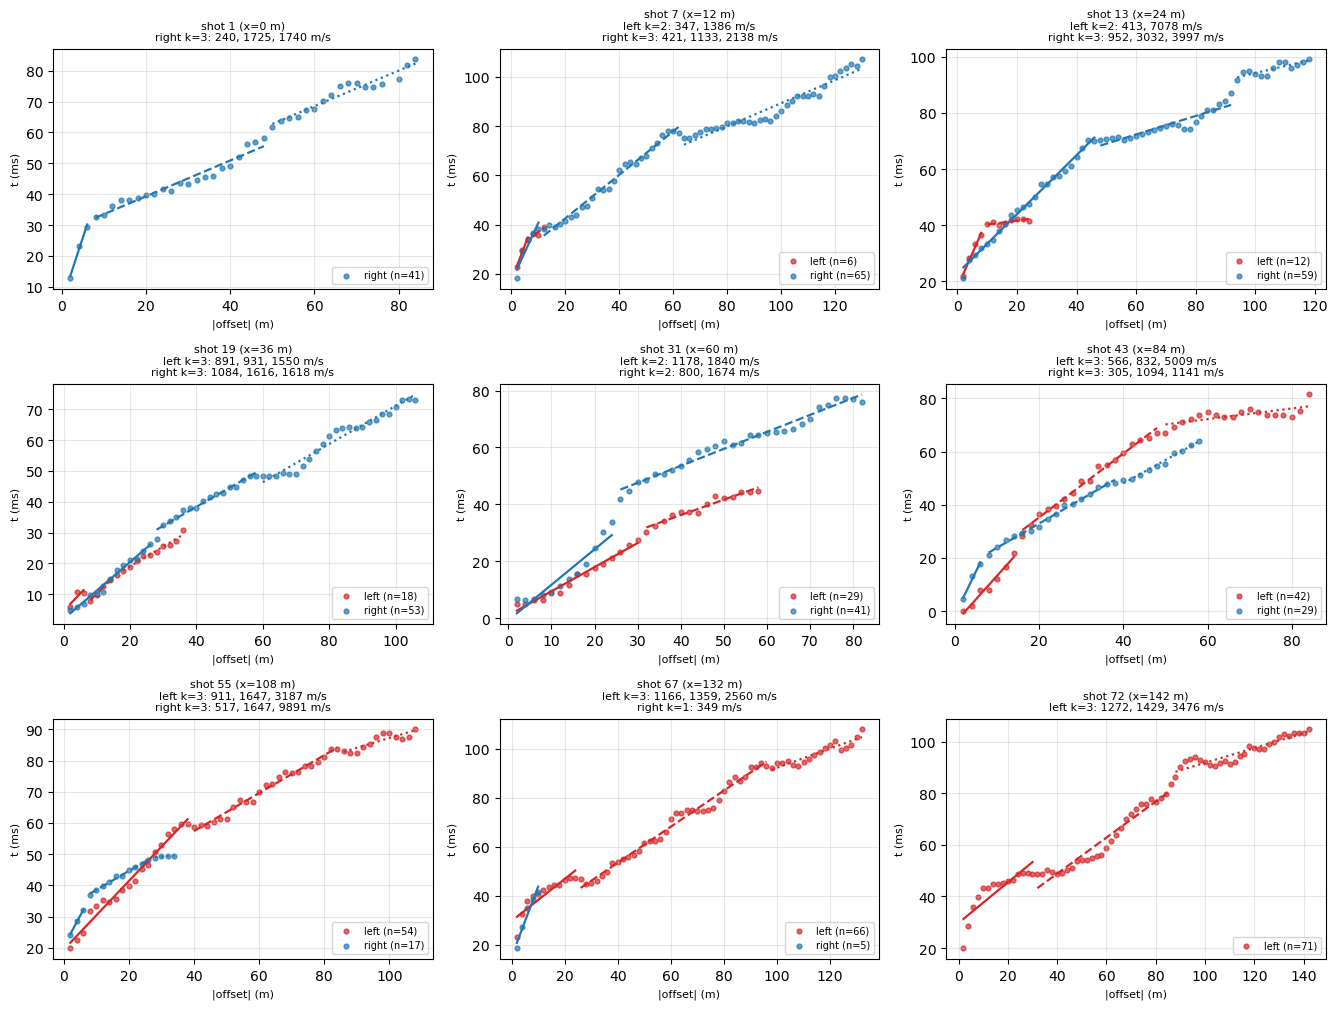

In [30]:
# load combined picks, fit each side of each shot independently, plot grid
import math

picks_path_all = r"../Refrapy/critter_springs_first_picks/picks/corrected_all_cs_picks_40-5hz_firsthits.sgt"
sensors_all, meas_all = read_sgt(picks_path_all)
shot_indices = np.unique(meas_all[:, 0].astype(int))
print(f"{len(shot_indices)} shots: {shot_indices.tolist()}")

# per-shot, per-side fits
results = {}
for s in shot_indices:
    sel  = meas_all[:, 0].astype(int) == s
    g    = meas_all[sel, 1].astype(int)
    tobs = meas_all[sel, 2]
    x_shot = sensors_all[s - 1, 0]
    x_off  = sensors_all[g - 1, 0] - x_shot

    info = {"x_shot": float(x_shot)}
    for name, mask in [("left", x_off < 0), ("right", x_off > 0)]:
        if mask.sum() < 2:
            info[name] = None
            continue
        d  = np.abs(x_off[mask])
        tt = tobs[mask]
        order = np.argsort(d)
        info[name] = {"d": d[order], "t": tt[order],
                      "fit": fit_piecewise(d[order], tt[order])}
    results[int(s)] = info

# plot grid: one panel per shot, both sides overlaid (left = red, right = blue)
n_shots = len(shot_indices)
ncols   = 3
nrows   = math.ceil(n_shots / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.4*nrows),
                         sharex=False, sharey=False)
axes = axes.flatten()

linestyles = ['-', '--', ':']
for idx, s in enumerate(shot_indices):
    ax    = axes[idx]
    info  = results[int(s)]
    x_shot = info["x_shot"]
    title_parts = [f"shot {s} (x={x_shot:.0f} m)"]

    for name, color in [("left", "tab:red"), ("right", "tab:blue")]:
        side = info[name]
        if side is None:
            continue
        d, tt = side["d"], side["t"]
        fit   = side["fit"]
        ax.scatter(d, tt*1000, color=color, s=12, alpha=0.7,
                   label=f"{name} (n={len(d)})")
        if fit is None:
            continue
        starts = [0] + fit["breaks"]
        ends   = fit["breaks"] + [len(d)]
        v_app  = [1.0/sl for sl in fit["slopes"]]
        for k in range(fit["k"]):
            xs = np.array([d[starts[k]], d[ends[k]-1]])
            ys = (fit["slopes"][k]*xs + fit["intercepts"][k]) * 1000
            ax.plot(xs, ys, color=color, lw=1.6, linestyle=linestyles[k])
        title_parts.append(
            f"{name} k={fit['k']}: " + ", ".join(f"{vi:.0f}" for vi in v_app) + " m/s"
        )

    ax.set_title("\n".join(title_parts), fontsize=8)
    ax.set_xlabel("|offset| (m)", fontsize=8)
    ax.set_ylabel("t (ms)", fontsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

for j in range(n_shots, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [31]:
# tabular summary of all per-side fits
print(f"{'Shot':>4} {'x_shot':>7} {'Side':>6} {'k':>2}  {'Velocities (m/s)':<24}  Depths (m)")
print("-" * 74)
for s in shot_indices:
    info = results[int(s)]
    x_shot = info['x_shot']
    for name in ('left', 'right'):
        side = info[name]
        if side is None:
            print(f"{s:>4} {x_shot:>7.1f} {name:>6}   - (no picks on this side)")
            continue
        fit = side['fit']
        if fit is None:
            print(f"{s:>4} {x_shot:>7.1f} {name:>6}   - (could not fit)")
            continue
        v, dpths = depths_from_fit(fit)
        v_str = ", ".join(f"{vi:.0f}" for vi in v)
        d_str = ", ".join(f"{di:.1f}" for di in dpths) if dpths else "-"
        print(f"{s:>4} {x_shot:>7.1f} {name:>6} {fit['k']:>2}  {v_str:<24}  {d_str}")


Shot  x_shot   Side  k  Velocities (m/s)          Depths (m)
--------------------------------------------------------------------------
   1     0.0   left   - (no picks on this side)
   1     0.0  right  3  240, 1725, 1740           3.4, 45.4
   7    12.0   left  2  347, 1386                 5.3
   7    12.0  right  3  421, 1133, 2138           5.7, 16.5
  13    24.0   left  2  413, 7078                 8.0
  13    24.0  right  3  952, 3032, 3997           26.3, 62.2
  19    36.0   left  3  891, 931, 1550            -0.9, 3.6
  19    36.0  right  3  1084, 1616, 1618          10.0, -71.0
  31    60.0   left  2  1178, 1840                11.1
  31    60.0  right  2  800, 1674                 13.5
  43    84.0   left  3  566, 832, 5009            4.3, 23.3
  43    84.0  right  3  305, 1094, 1141           2.3, -1.0
  55   108.0   left  3  911, 1647, 3187           18.1, 35.1
  55   108.0  right  3  517, 1647, 9891           8.8, 18.9
  67   132.0   left  3  1166, 1359, 2560          27.2

## Shot-gather QC: wiggles with picks overlaid

For each shot, the bandpass-filtered shot gather is plotted with the Refrapy picks (red) overlaid at each geophone position. The blue dashed line marks the shot location. This is the visual check that the picks you've fed into the velocity inversions actually track the first breaks at every offset — if a pick is consistently sitting *above* or *below* the true first arrival on a particular shot, every velocity in the inversion that uses that pick is wrong.

Bandpass is set to **5–40 Hz** to match the filename of the pick file (`..._40-5hz_firsthits.sgt`); change `freqmin` / `freqmax` below if the picks were made on a different band.

The `shot_to_file` dict assumes `.dat` files are numbered in shot order (1001 = shot 1, 1002 = shot 7, …, 1009 = shot 72). If that's wrong for your project, edit the mapping.


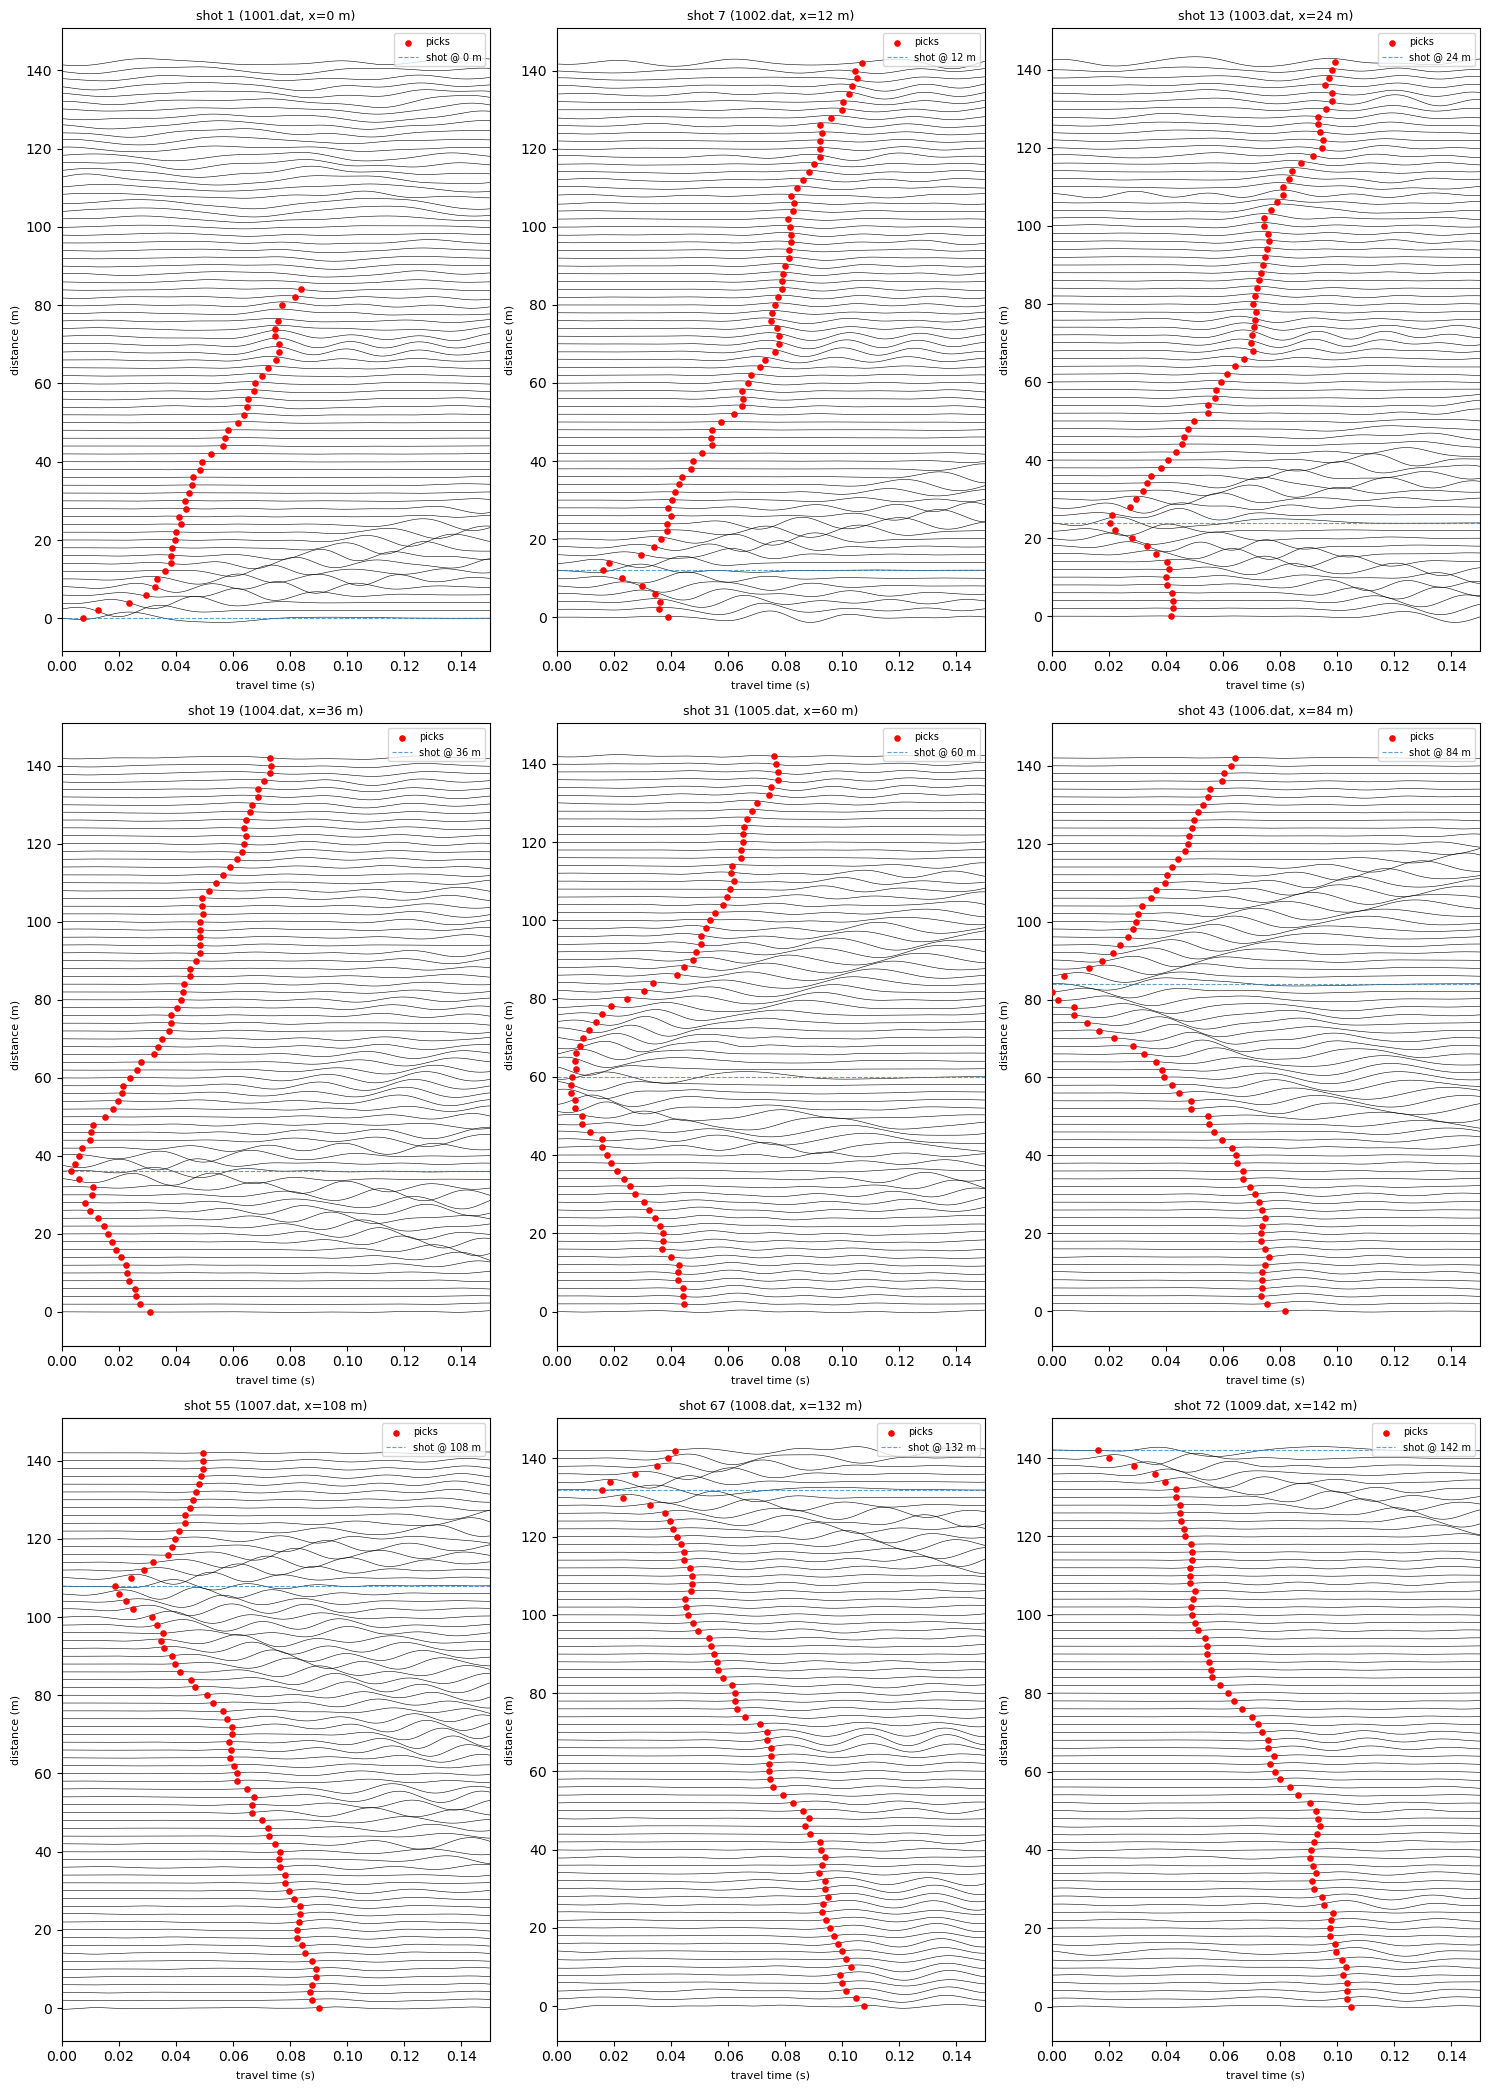

In [32]:
# QC: wiggles with picks overlaid for every shot
# .dat file number -> shot index in the picks file. Adjust here if the order differs.
shot_to_file = {
    1:  "1001.dat",
    7:  "1002.dat",
    13: "1003.dat",
    19: "1004.dat",
    31: "1005.dat",
    43: "1006.dat",
    55: "1007.dat",
    67: "1008.dat",
    72: "1009.dat",
}

freqmin, freqmax = 5.0, 40.0   # bandpass matching the pick file "40-5hz"
separation       = 2           # geophone spacing (m)
xlim_t           = (0, 0.15)   # zoom to first arrivals (s)

ncols = 3
nrows = math.ceil(len(shot_indices) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 7*nrows))
axes = axes.flatten()

for idx, s in enumerate(shot_indices):
    ax = axes[idx]
    s  = int(s)
    fname = shot_to_file.get(s)
    if fname is None:
        ax.set_title(f"shot {s}: no .dat mapping", fontsize=9)
        ax.axis('off')
        continue

    try:
        st = read(f"../Data/{fname}")
    except Exception as e:
        ax.set_title(f"shot {s}: cannot read {fname}\n{e}", fontsize=8)
        ax.axis('off')
        continue

    st_f = st.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax,
                            corners=4, zerophase=True)

    for ch in range(len(st_f)):
        tr = st_f[ch]
        amax = abs(tr.data).max()
        if amax > 0:
            ax.plot(tr.times(), 0.8*separation*tr.data/amax + ch*separation,
                    color='black', lw=0.4)

    # overlay picks for this shot
    sel = meas_all[:, 0].astype(int) == s
    g_picks = meas_all[sel, 1].astype(int)
    t_picks = meas_all[sel, 2]
    y_picks = (g_picks - 1) * separation
    ax.scatter(t_picks, y_picks, color='red', s=14, zorder=10, label='picks')

    # mark shot position
    x_shot = sensors_all[s - 1, 0]
    ax.axhline(x_shot, color='tab:blue', linestyle='--', lw=0.8, alpha=0.7,
               label=f'shot @ {x_shot:.0f} m')

    ax.set_xlim(xlim_t)
    ax.set_title(f"shot {s} ({fname}, x={x_shot:.0f} m)", fontsize=9)
    ax.set_xlabel("travel time (s)", fontsize=8)
    ax.set_ylabel("distance (m)", fontsize=8)
    ax.legend(fontsize=7, loc='upper right')

for j in range(len(shot_indices), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## Reciprocity check

For any pair of shots **A** and **B** that are both also recorded as receivers, the travel time from A to B must equal the travel time from B to A (in a passive, isotropic medium). Comparing `t(shot=A, geophone=B)` against `t(shot=B, geophone=A)` is a direct QC on (1) picking consistency, (2) shot-time / instrument timing, and (3) shot-geophone geometry.

- **Left panel**: scatter of `t(A→B)` vs `t(B→A)`. Points should fall on `y = x`.
- **Right panel**: residual `Δt = t(A→B) − t(B→A)` vs offset, with mean and ±1σ band annotated. Each point is labeled with the shot pair `A-B`.

Large residuals on a single pair point to a bad pick on one of the two traces. A nonzero *mean* (systematic bias) across all pairs is more concerning — it suggests a shot-time clock offset between the two halves of the spread.


32 reciprocal pairs found
Residual stats (ms):  mean = +0.102,  std = 12.338,  median|res| = 3.871,  max|res| = 25.030


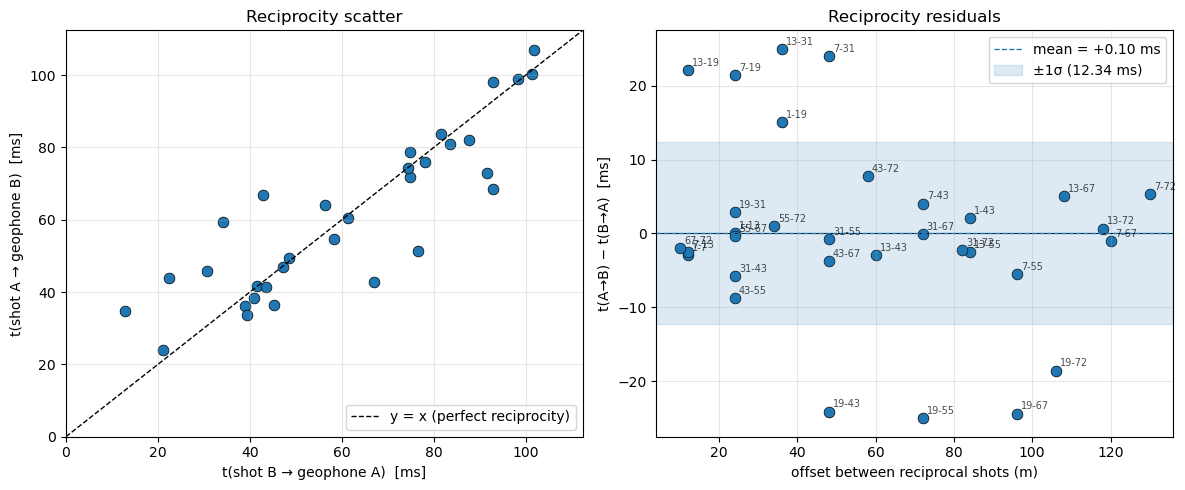


  A   B    x_A    x_B  offset   t(A→B) ms   t(B→A) ms    Δt ms
----------------------------------------------------------------
  1   7    0.0   12.0    12.0       36.17       39.06    -2.89
  1  13    0.0   24.0    24.0       41.62       41.62    +0.00
  1  19    0.0   36.0    36.0       45.79       30.72   +15.07
  1  43    0.0   84.0    84.0       83.63       81.52    +2.11
  7  13   12.0   24.0    12.0       38.42       40.98    -2.56
  7  19   12.0   36.0    24.0       43.87       22.38   +21.48
  7  31   12.0   60.0    48.0       66.95       42.91   +24.05
  7  43   12.0   84.0    72.0       78.82       74.78    +4.04
  7  55   12.0  108.0    96.0       82.03       87.58    -5.55
  7  67   12.0  132.0   120.0      100.31      101.38    -1.07
  7  72   12.0  142.0   130.0      107.04      101.72    +5.32
 13  19   24.0   36.0    12.0       34.89       12.76   +22.13
 13  31   24.0   60.0    36.0       59.26       34.25   +25.01
 13  43   24.0   84.0    60.0       71.85       74.7

In [33]:
# build a lookup of every pick by (shot_idx, geophone_idx)
picks_lookup = {(int(r[0]), int(r[1])): r[2] for r in meas_all}

# reciprocal pairs: shot A at geophone position G_A, shot B at G_B
# we want t(shot=A, g=B) vs t(shot=B, g=A) -- both must exist in the picks
pairs = []
for i, sa in enumerate(shot_indices):
    for sb in shot_indices[i+1:]:
        t_ab = picks_lookup.get((int(sa), int(sb)))
        t_ba = picks_lookup.get((int(sb), int(sa)))
        if t_ab is None or t_ba is None:
            continue
        xa, xb = sensors_all[int(sa)-1, 0], sensors_all[int(sb)-1, 0]
        pairs.append({
            "sa": int(sa), "sb": int(sb),
            "xa": float(xa), "xb": float(xb),
            "offset": float(abs(xb - xa)),
            "t_ab": float(t_ab), "t_ba": float(t_ba),
            "residual": float(t_ab - t_ba),
        })

print(f"{len(pairs)} reciprocal pairs found")
residuals_ms = np.array([p["residual"] for p in pairs]) * 1000
offsets      = np.array([p["offset"]   for p in pairs])
t_ab_ms      = np.array([p["t_ab"]     for p in pairs]) * 1000
t_ba_ms      = np.array([p["t_ba"]     for p in pairs]) * 1000

print(f"Residual stats (ms):  mean = {residuals_ms.mean():+.3f},  "
      f"std = {residuals_ms.std():.3f},  "
      f"median|res| = {np.median(np.abs(residuals_ms)):.3f},  "
      f"max|res| = {np.max(np.abs(residuals_ms)):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# left: t_AB vs t_BA, should fall on y = x
ax1.scatter(t_ba_ms, t_ab_ms, s=60, color='tab:blue', edgecolor='k', lw=0.5)
lim = [0, max(t_ab_ms.max(), t_ba_ms.max()) * 1.05]
ax1.plot(lim, lim, 'k--', lw=1, label='y = x (perfect reciprocity)')
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("t(shot B → geophone A)  [ms]")
ax1.set_ylabel("t(shot A → geophone B)  [ms]")
ax1.set_title("Reciprocity scatter")
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# right: residual vs offset
ax2.axhline(0, color='k', lw=0.7)
ax2.scatter(offsets, residuals_ms, s=60, edgecolor='k', lw=0.5)
mu, sd = residuals_ms.mean(), residuals_ms.std()
ax2.axhline(mu, color='tab:blue', lw=1, linestyle='--', label=f'mean = {mu:+.2f} ms')
ax2.axhspan(mu - sd, mu + sd, color='tab:blue', alpha=0.15, label=f'±1σ ({sd:.2f} ms)')
for p in pairs:
    ax2.annotate(f"{p['sa']}-{p['sb']}", (p['offset'], p['residual']*1000),
                 fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')
ax2.set_xlabel("offset between reciprocal shots (m)")
ax2.set_ylabel("t(A→B) − t(B→A)  [ms]")
ax2.set_title("Reciprocity residuals")
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print()
print(f"{'A':>3} {'B':>3} {'x_A':>6} {'x_B':>6} {'offset':>7} "
      f"{'t(A→B) ms':>11} {'t(B→A) ms':>11} {'Δt ms':>8}")
print("-" * 64)
for p in pairs:
    print(f"{p['sa']:>3} {p['sb']:>3} {p['xa']:>6.1f} {p['xb']:>6.1f} "
          f"{p['offset']:>7.1f} {p['t_ab']*1000:>11.2f} {p['t_ba']*1000:>11.2f} "
          f"{p['residual']*1000:>+8.2f}")
